# 第 09 章 子群分析

## 学习目标

比较在现有图中限制聚类与提取子集后重建图的两种分析方法。

## 为什么做与怎样做

以 B 细胞为例，分别执行 restrict_to 聚类和子集内重新归一化、高变基因筛选、PCA、邻居图及聚类；保存子集结果。

前置章节：08。运行前请完成项目环境准备。


In [1]:
from __future__ import annotations
from pathlib import Path
import os
import sys
ROOT = Path(os.environ.get("SC_COURSE_ROOT", Path.cwd())).resolve()
while not (ROOT / "config/course.json").is_file() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "config/course.json").is_file():
    raise RuntimeError("请从课程目录或其 notebooks/exercises 目录运行。")
os.environ["CELLTYPIST_FOLDER"] = str(ROOT / ".runtime/celltypist")
os.environ["MPLCONFIGDIR"] = str(ROOT / ".runtime/matplotlib")
sys.path.insert(0, str(ROOT / "tools"))
from course_runtime import start_chapter, marker_sets, scaled_view
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation
ctx = start_chapter("09")
adata = ctx.load_input()
sets = marker_sets(adata)
markers_1, markers_2 = sets["fine"], sets["broad"]
markers = markers_1
leiden_res = "leiden_res_0_50"


第 09 章：子群分析
结果目录：results/09_subclustering/20260915T074942_425323


读取检查点：results/08_manual_annotation/20260915T074833_dd2e88/checkpoint.h5ad
17,041 个细胞 × 23,427 个基因


## 09.1 子聚类二次聚类注释

0.5分辨率似乎能区分数据中的大多数细胞类型。接下来，还应逐簇深入检查，必要时进行子聚类。

## 09.2 方法1：直接指定子类细胞类型进行子聚类

In [2]:
# 功能说明：查看细胞注释表。
# 运行目的：检查当前的注释状态，为子聚类做准备。
# 详细代码解析：
# 1. `adata.obs`
#    - 打印概览。

adata.obs

,samples,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,n_genes,doublet_score,predicted_doublet,leiden_res_0_02,leiden_res_0_50,leiden_res_1_00,leiden_res_2_00,cell_type_res_0.02_lvl1,cell_type_res_0.50_lvl1,cell_type_res_0.50_lvl2
AAACCCAAGGATGGCT-1,s1d1,2103,7.651596,8663.0,9.066932,42.721921,59.667552,69.744892,79.348955,460.0,...,2103,0.036113,False,0,0,0,0,Immune_mixed,T_NK_ILCs,Naive_memory_T
AAACCCAAGGCCTAGA-1,s1d1,3916,8.273081,12853.0,9.461411,35.843772,44.262040,52.376877,62.763557,1790.0,...,3912,0.183381,False,1,3,1,1,Myeloid,Myeloid,CD14_Mono
AAACCCAAGTGAGTGC-1,s1d1,683,6.527958,1631.0,7.397562,56.284488,62.599632,70.386266,88.779890,581.0,...,683,0.045320,False,2,4,2,2,B_cells,B_cells,Naive_B
AAACCCACAAGAGGCT-1,s1d1,4330,8.373554,17345.0,9.761117,27.662150,38.420294,48.901701,62.023638,780.0,...,4328,0.045320,False,0,5,3,3,Immune_mixed,Myeloid,pDC
AAACCCACATCGTGGC-1,s1d1,325,5.786897,555.0,6.320768,49.909910,59.459459,77.477477,100.000000,159.0,...,323,0.016181,False,0,1,4,4,Immune_mixed,Uncertain,Low_quality_lymphoid_like
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGAGAGTCTGG-1,s1d3,277,5.627621,615.0,6.423247,63.089431,71.219512,87.479675,100.000000,282.0,...,277,0.032046,False,0,1,5,8,Immune_mixed,Uncertain,Low_quality_lymphoid_like
TTTGTTGCAGACAATA-1,s1d3,3797,8.242230,13218.0,9.489410,30.753518,44.628537,53.691935,64.684521,864.0,...,3795,0.078619,False,1,3,1,1,Myeloid,Myeloid,CD14_Mono
TTTGTTGCATGTTACG-1,s1d3,3089,8.035926,27280.0,10.213945,64.409824,71.671554,78.317449,85.054985,1025.0,...,3087,0.033898,False,4,11,14,30,Erythroid,Erythroid,Cycling_erythroid
TTTGTTGGTAGTCACT-1,s1d3,379,5.940171,698.0,6.549651,52.865330,60.028653,74.355301,100.000000,143.0,...,379,0.039080,False,0,1,7,7,Immune_mixed,Uncertain,Low_quality_lymphoid_like


In [3]:
# 功能说明：对特定细胞群进行子聚类。
# 运行目的：在 "B_cells" 大类内部进行更细致的聚类（分辨率 0.05），以发现潜在的亚群。
# 详细代码解析：
# 1. `sc.tl.leiden(...)`
#    - `restrict_to=('cell_type_res_0.02_lvl1', ['B_cells', ])`:
#      - 仅对 `cell_type_res_0.02_lvl1` 列中标记为 `B_cells` 的细胞进行聚类。
#      - 其他细胞的标签保持不变（或设为 NaN/默认值）。
#    - `resolution=0.05`: 使用极低的分辨率，因为是在较小的子集上操作。
#    - `key_added='leiden_sub', flavor='leidenalg', n_iterations=-1, random_state=0, neighbors_key=adata.uns['course_neighbors_key']`: 结果存储在 `leiden_sub` 列。

sc.tl.leiden(
    adata,
    resolution=0.05,
    restrict_to=('cell_type_res_0.02_lvl1', ['B_cells', ]),  # 在一个大类内部分别聚类，当然也可以提供多个
    key_added='leiden_sub', flavor='leidenalg', n_iterations=-1, random_state=0, neighbors_key=adata.uns['course_neighbors_key']
)

/tmp/ipykernel_1296756/3666773531.py:11: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


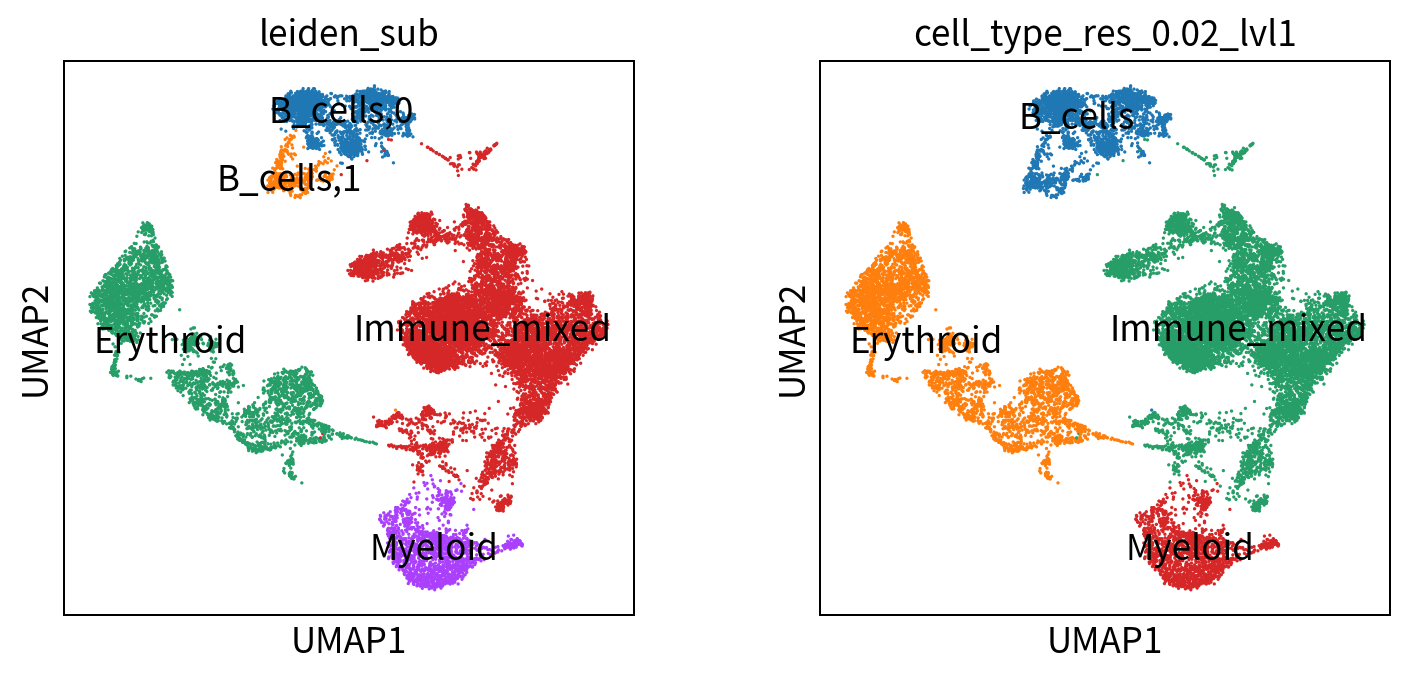

In [4]:
# 功能说明：绘制子聚类结果的 UMAP 图。
# 运行目的：可视化 B 细胞内部的亚群结构。
# 详细代码解析：
# 1. `sc.pl.umap(...)`
#    - `color=["leiden_sub", ...]` : 展示子聚类标签。

sc.pl.umap(
        adata,
        color=["leiden_sub", "cell_type_res_0.02_lvl1", ],
        legend_loc="on data",
        save="_09_218.pdf",
        )

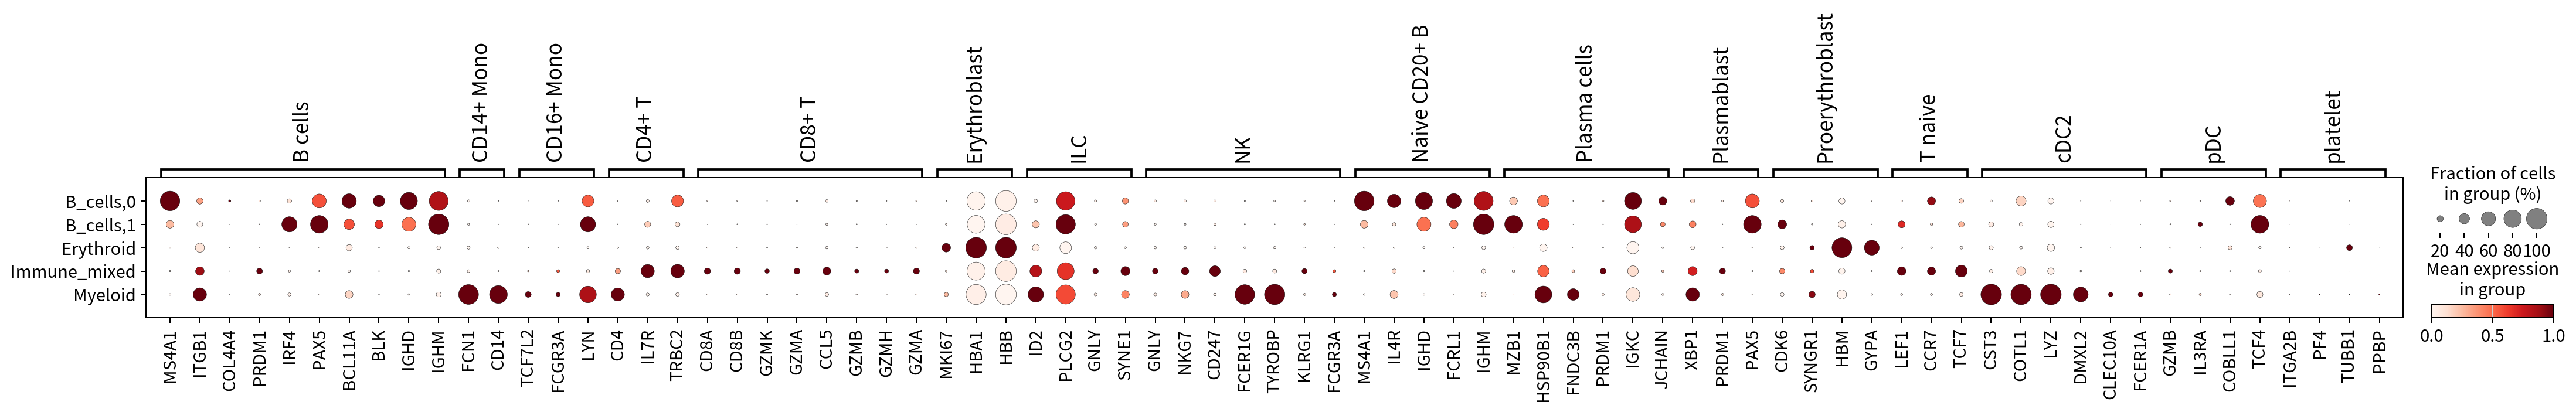

In [5]:
# 功能说明：用点图展示各簇的标记基因表达水平。进行注释
sc.pl.dotplot(adata, markers, groupby="leiden_sub", standard_scale="var", save="_09_219.pdf")

## 09.3 方法2：提取指定子类细胞类型所有细胞为新的adata数据，然后进行完整的基础分析

In [6]:
# 提取B细胞子集
sub_cluster = adata.obs["cell_type_res_0.02_lvl1"] == "B_cells"
adata_sub = adata[sub_cluster].copy()
if adata_sub.n_obs < 51:
    raise ValueError("B 细胞不足 51 个，请先核对注释和子群分析参数。")
# 将原始计数复制到X中，重新进行标准化
adata_sub.X = adata_sub.layers['counts'].copy()
# 重新进行分析流程
sc.pp.normalize_total(adata_sub)
sc.pp.log1p(adata_sub)
adata_sub.layers["log1p"] = adata_sub.X.copy()
sc.pp.highly_variable_genes(adata_sub, n_top_genes=2000, batch_key="samples")
sc.tl.pca(adata_sub)
sc.pp.neighbors(adata_sub,random_state=0)
sc.tl.umap(adata_sub,random_state=0)
sc.tl.leiden(adata_sub, key_added="leiden_sub", resolution=0.05, flavor="igraph", n_iterations=-1, directed=False, random_state=0)



/data/home/heqingchuan/workdir/19_方超老师合作_单细胞_gpt6/sc_RNA/sc_RNA_basic_course/.envs/sc_rna/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


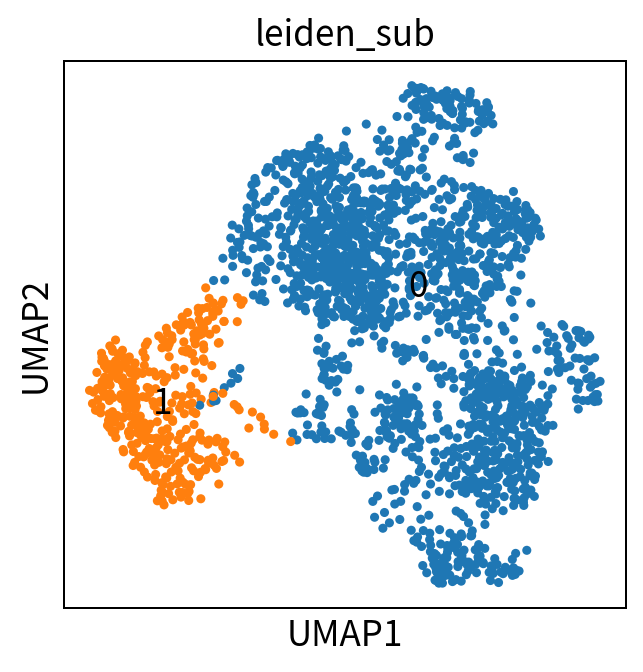

In [7]:
# 功能说明：绘制提取子集后的 UMAP 图。
# 运行目的：可视化仅包含 B 细胞的独立分析结果。
# 详细代码解析：
# 1. `sc.pl.umap(...)`
#    - `adata_sub`: 使用提取出的 B 细胞子集对象。

sc.pl.umap(
    adata_sub,
    color=["leiden_sub"],
    legend_loc="on data",
    save="_09_222.pdf",
)

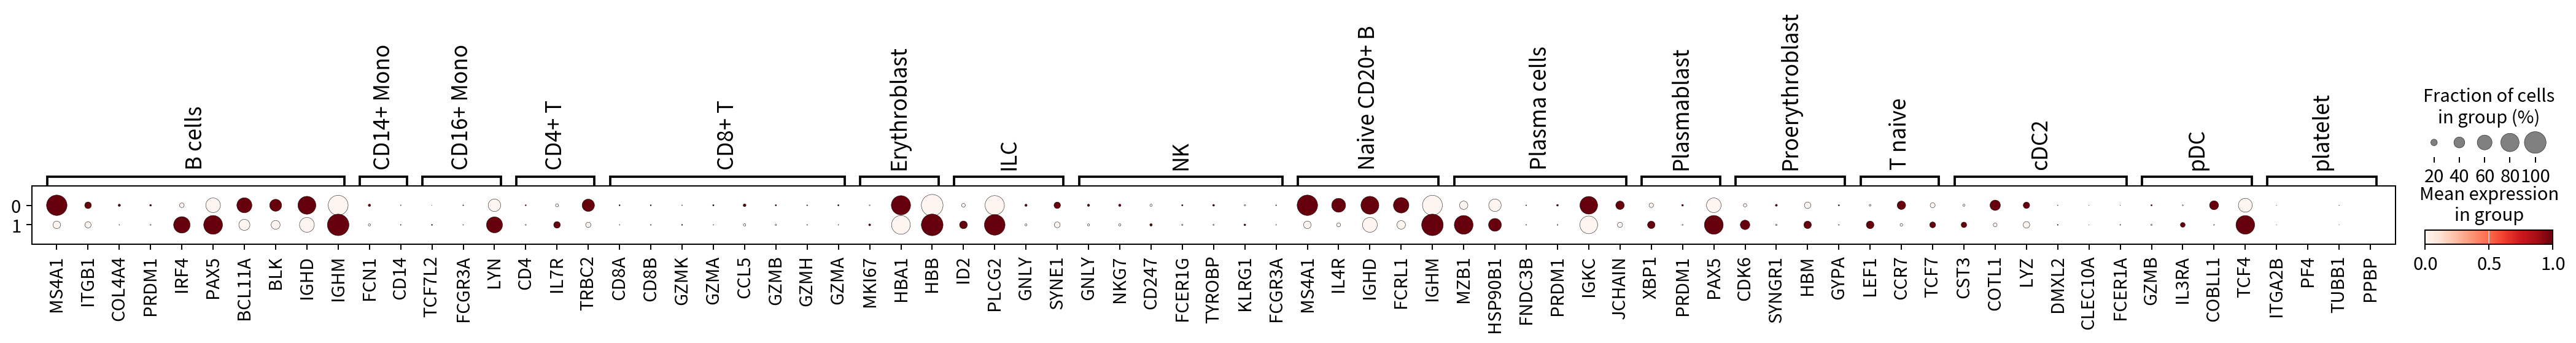

In [8]:
# 功能说明：用点图展示各簇的标记基因表达水平。进行注释
sc.pl.dotplot(adata_sub, markers, groupby="leiden_sub", standard_scale="var", save="_09_223.pdf")

## 09.4 树状图
大多数可视化可以使用树状图排列类别。但是，树状图也可以独立绘制，如下所示：

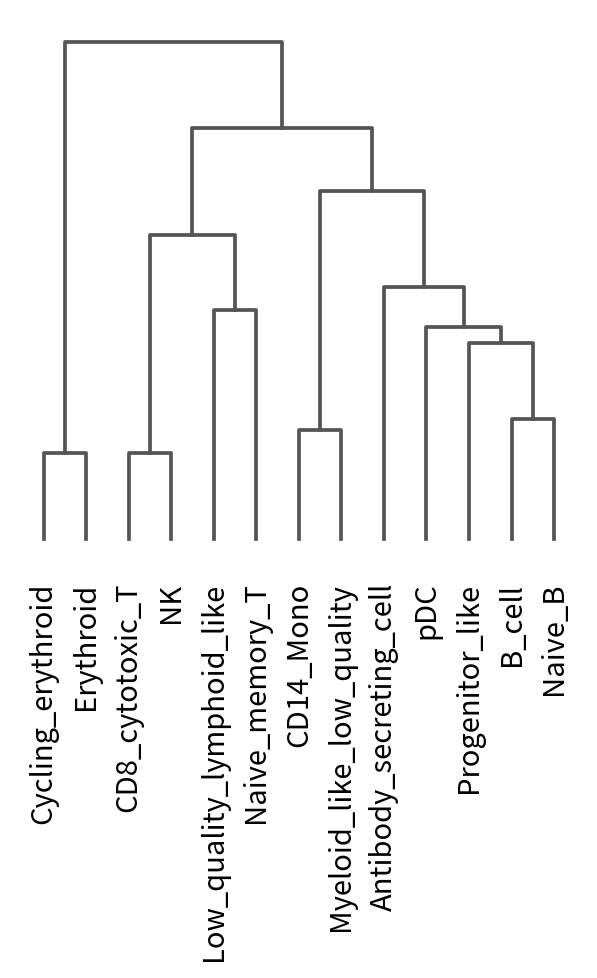

In [9]:
# 指定注释的结果
cell_type = "cell_type_res_0.50_lvl2"


# 功能说明：计算层次聚类树状图。
# 运行目的：确定不同类别（如 cell_type）之间的相似性关系，用于后续绘图排序。
# 变量/函数/参数解析：
# - sc.tl.dendrogram(adata, cell_type)：
#   - adata：AnnData 对象。
#   - "bulk_labels"：要进行聚类的分组变量。
#   - 该函数使用主成分（PCs）计算距离，并进行层次聚类。
#   - 结果存储在 adata.uns['dendrogram_cell_type'] 中。

# 使用 PC 计算层次聚类（可以使用多种距离度量和链接方法）。
sc.tl.dendrogram(adata, cell_type)

# 功能说明：绘制树状图。
# 运行目的：可视化类别之间的层次关系。
# 变量/函数/参数解析：
# - sc.pl.dendrogram(...)：
#   - 绘制之前计算的树状图。
#   - cell_type：指定要绘制的分组变量。

ax = sc.pl.dendrogram(adata, cell_type,save="_09_225.pdf")

## 09.5 绘制相关性热图

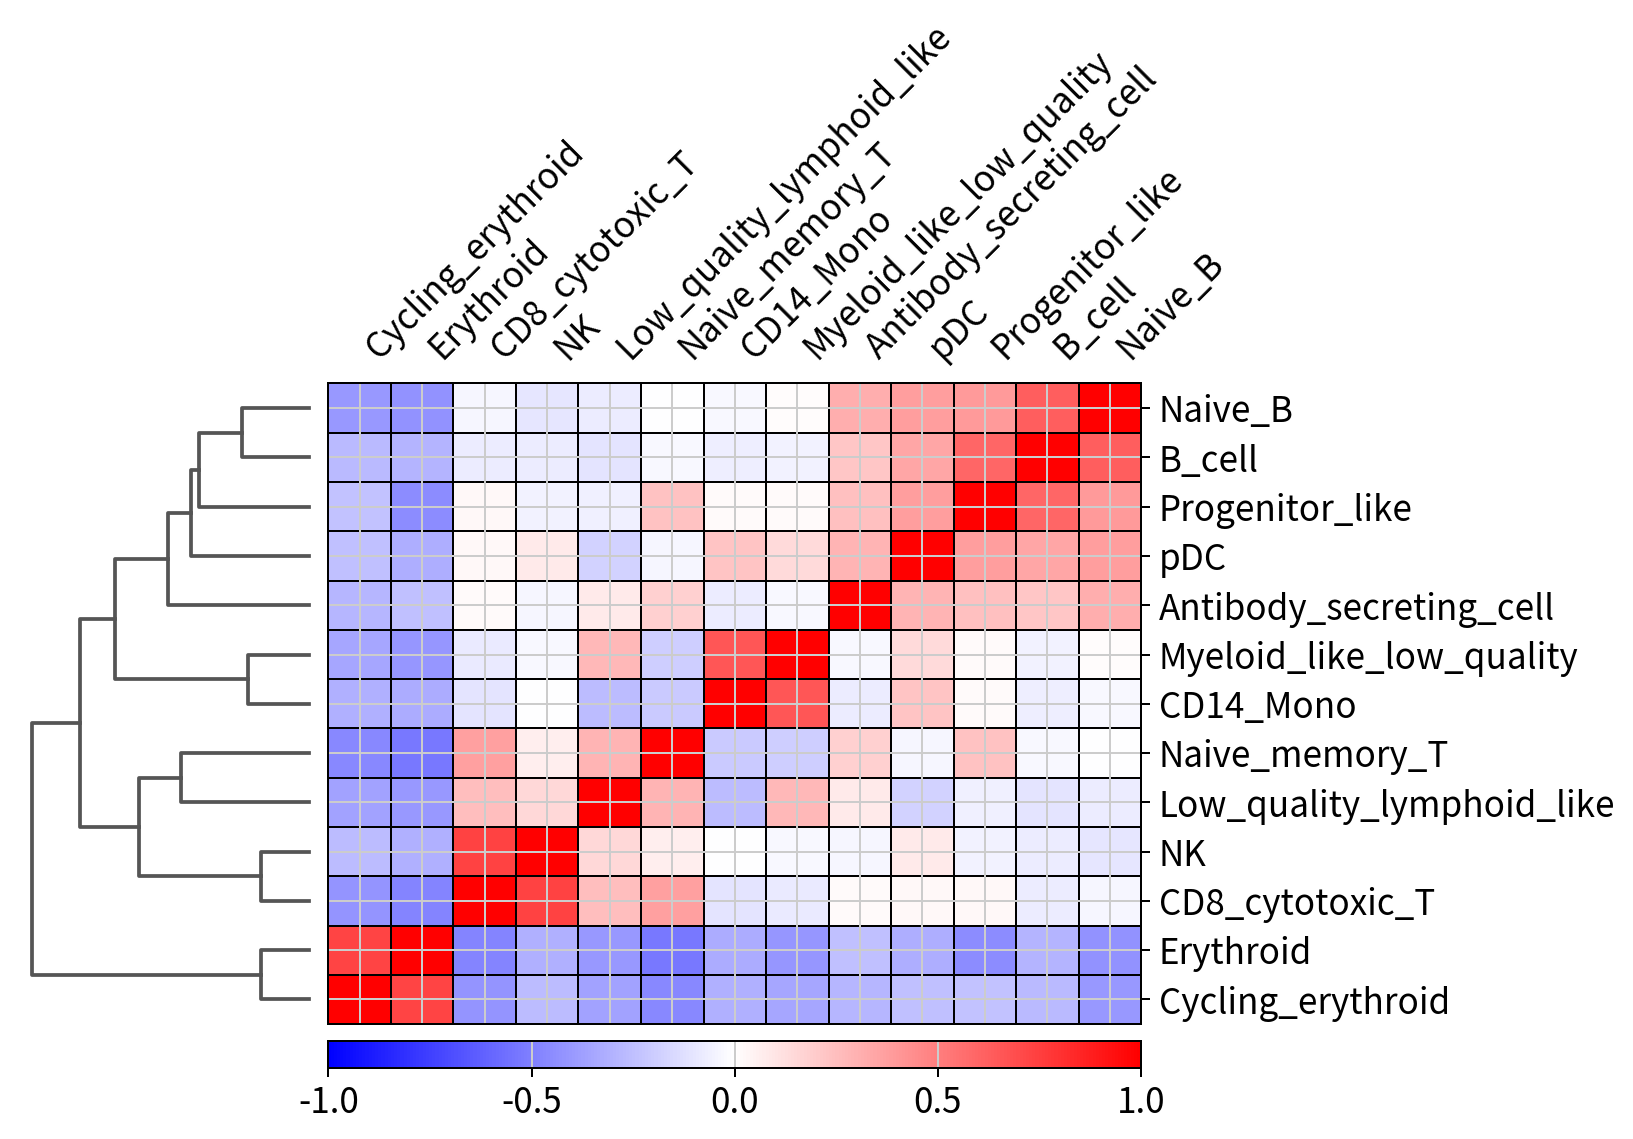

In [10]:
# 指定注释的结果
cell_type = "cell_type_res_0.50_lvl2"


# 功能说明：绘制相关性矩阵图。
# 运行目的：展示不同类别之间的相关性系数，结合树状图可以更直观地理解类别间的相似度。
# 变量/函数/参数解析：
# - sc.pl.correlation_matrix(...)：
#   - adata：AnnData 对象。
#   - cell_type：分组变量。
#   - figsize=(5, 3.5)：设置图形大小。
#   - 默认使用 Pearson 相关系数。

ax = sc.pl.correlation_matrix(adata, cell_type, figsize=(8, 5),save="_09_227.pdf")

## 保存本章结果

保存表格、参数摘要和可供后续章节读取的数据。

In [11]:
adata_sub.write_h5ad(ctx.directory / "b_cells_subset.h5ad", compression="gzip")
ctx.table("b_cell_subclusters", adata_sub.obs)
ctx.table("restricted_subclusters", adata.obs[["leiden_sub", "cell_type_res_0.02_lvl1"]])
ctx.finish(adata, {"b_cells": int(adata_sub.n_obs), "subset_clusters": int(adata_sub.obs["leiden_sub"].nunique())})

本章计算完成。请阅读本次图表和表格，再更新本章解读。


## 结果阅读与思考

请打开本次结果目录中的 summary.json、tables 和 figures。将目的、方法、结果和解释写入本章报告源稿，再更新 Word。

思考题：两种子聚类方法的邻居图为什么可能不同？

运行与报告操作见课程根目录的 99_运行与AI协作指南.md。